Generating simulated historical minute data...
Initializing Local Engine Backtest...
          STRATEGY PERFORMANCE REPORT          
Total Underlying Asset Return : -435.03%
Total Strategy Return         : -104.86%
--------------------------------------------------
Annualized Sharpe Ratio       : -0.8862


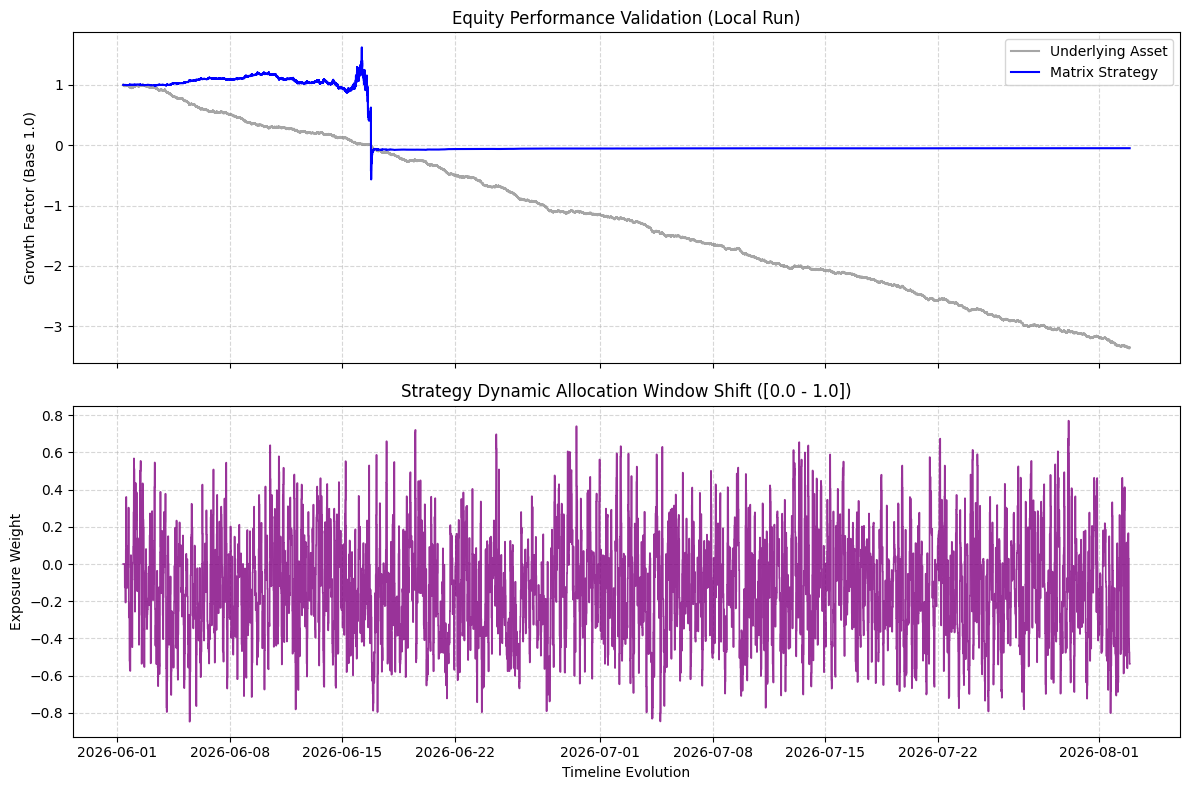

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

class LocalMatrixBacktester:
    def __init__(self, df, initial_cash=2000000):
        """
        Expects a pandas DataFrame with:
        - A DatetimeIndex (or a column named 'DateTime' containing parsed datetimes)
        - A column named 'Close' containing numeric asset prices
        """
        self.df = df.copy()
        
        # Standardize Datetime formatting
        if 'DateTime' not in self.df.columns:
            if isinstance(self.df.index, pd.DatetimeIndex):
                self.df['DateTime'] = self.df.index
            else:
                raise ValueError("DataFrame must contain a 'DateTime' column or use a valid DatetimeIndex.")
        
        # Ensure data is sorted chronologically
        self.df = self.df.sort_values('DateTime').reset_index(drop=True)
        
        # Core Strategy Parameters
        self.e = 0.01
        self.Ts = 80
        self.sigmao = 0.1
        self.T = 30
        self.max_Tl = 130
        self.tl_range = np.arange(115, 131)  # 16 ensemble members
        self.num_models = len(self.tl_range)
        
        # Incremental Streaming Variance Accumulators
        self.n_difs = 0
        self.sum_difs = 0.0
        self.sum_sq_difs = 0.0
        
        # Signal Accumulation Matrix (Rows: Timesteps, Columns: Ensemble Models)
        self.signal_matrix = np.full((len(self.df), self.num_models), np.nan)
        
        # Target Allocations tracking array
        self.allocations = np.zeros(len(self.df))
        
    def run_backtest(self):
        closes = self.df['Close'].values
        times = self.df['DateTime'].tolist()
        
        step_counter = 0
        current_allocation = 0.0
        
        # Loop sequentially through the timeline to mimic historical streaming bars
        for i in range(len(self.df)):
            if i >= (self.max_Tl + 1):
                if step_counter % self.T == 0:
                    hist_closes = closes[:i]
                    hist_times = times[:i]
                    current_allocation = self._execute_strategy_logic(i, hist_closes, hist_times)
                
                step_counter += 1
            
            self.allocations[i] = current_allocation
            
            if i >= 1:
                if times[i].date() == times[i-1].date():
                    dif = closes[i] - closes[i-1]
                    self.n_difs += 1
                    self.sum_difs += dif
                    self.sum_sq_difs += dif ** 2
                    
        # Append tracking outcomes to DataFrame
        self.df['Target_Allocation'] = self.allocations
        self._calculate_returns()
        return self.df

    def _execute_strategy_logic(self, current_idx, hist_closes, hist_times):
        if self.n_difs == 0:
            return 0.0

        mean_dif = self.sum_difs / self.n_difs
        variance = (self.sum_sq_difs / self.n_difs) - (mean_dif ** 2)
        sigma = np.sqrt(max(1e-9, variance))
        rho = (sigma / self.sigmao) ** 2

        raw_difs = np.diff(hist_closes) 
        for j in range(len(raw_difs)):
            if hist_times[j+1].date() != hist_times[j].date():
                raw_difs[j] = 0.0

        small_mean = np.mean(raw_difs[-self.Ts:])
        long_means = np.array([np.mean(raw_difs[-Tl:]) for Tl in self.tl_range])

        a = small_mean / (1 + rho / self.Ts)
        b_vec = long_means / (1 + rho / self.tl_range)
        denominator = ((a - b_vec) ** 2) + 1e-9
        T_vec = (-1 * np.log(self.e) * 2 * (sigma ** 2)) / denominator

        # Precompute baseline anchor to prevent NoneType edge case failures
        ind_true_base = self.T * a
        ind_false_base = T_vec * a + (self.T - T_vec) * (self.e * a + (1 - self.e) * b_vec)
        baseline_ind_vector = np.where(T_vec > self.T, ind_true_base, ind_false_base)

        # Continuous Look-Forward Sweep (T to T + 30)
        for t_horizon in range(self.T, self.T + 31):
            future_step = current_idx + t_horizon
            if future_step >= len(self.df):
                break
            
            ind_true = t_horizon * a
            ind_false = T_vec * a + (t_horizon - T_vec) * (self.e * a + (1 - self.e) * b_vec)
            ind_vector = np.where(T_vec > t_horizon, ind_true, ind_false)

            calculated_move_vec = np.tanh(ind_vector)
            weight = np.exp(-(t_horizon - self.T))
            decayed_signal_vec = calculated_move_vec * weight
            
            if np.isnan(self.signal_matrix[future_step]).all():
                self.signal_matrix[future_step] = decayed_signal_vec
            else:
                self.signal_matrix[future_step] = np.nan_to_num(self.signal_matrix[future_step]) + decayed_signal_vec

        current_aggregated_signal = self.signal_matrix[current_idx]

        if np.isnan(current_aggregated_signal).any():
            current_aggregated_signal = np.tanh(baseline_ind_vector)

        max_ind = np.max(baseline_ind_vector)
        exp_ind = np.exp(np.abs(baseline_ind_vector) - max_ind)
        softmax_weights = exp_ind / np.sum(exp_ind)

        blended_move = np.sum(softmax_weights * current_aggregated_signal)

        return float(np.clip(blended_move, -1.0, 1.0))

    def _calculate_returns(self):
        """ Computes financial equity curves directly on the DataFrame """
        self.df['Asset_Return'] = self.df['Close'].pct_change().fillna(0)
        # Shift target allocation by 1 bar to prevent lookahead execution bias
        self.df['Executed_Allocation'] = self.df['Target_Allocation'].shift(1).fillna(0)
        self.df['Strategy_Return'] = self.df['Executed_Allocation'] * self.df['Asset_Return']
        
        # Compile equity indexing
        self.df['Cumulative_Asset'] = (1 + self.df['Asset_Return']).cumprod()
        self.df['Cumulative_Strategy'] = (1 + self.df['Strategy_Return']).cumprod()

    def print_performance_metrics(self):
        """ Computes and logs performance summary stats """
        total_asset_return = (self.df['Cumulative_Asset'].iloc[-1] - 1) * 100
        total_strat_return = (self.df['Cumulative_Strategy'].iloc[-1] - 1) * 100
        
        # Annualization factor setup: 390 standard daily trading minutes * 252 trading days
        annualization_factor = np.sqrt(375 * 252)
        
        strat_returns = self.df['Strategy_Return']
        mean_return = strat_returns.mean()
        std_return = strat_returns.std()
        
        if std_return > 0:
            sharpe_ratio = (mean_return / std_return) * annualization_factor
        else:
            sharpe_ratio = 0.0

        print("=" * 50)
        print("          STRATEGY PERFORMANCE REPORT          ")
        print("=" * 50)
        print(f"Total Underlying Asset Return : {total_asset_return:.2f}%")
        print(f"Total Strategy Return         : {total_strat_return:.2f}%")
        print("-" * 50)
        print(f"Annualized Sharpe Ratio       : {sharpe_ratio:.4f}")
        print("=" * 50)


# =========================================================================
# LOCAL VERIFICATION RUNNER
# =========================================================================
if __name__ == "__main__":
    print("Generating simulated historical minute data...")
    np.random.seed(42)
    
    # Generate 5 full US market trading days (390 mins * 5 = 1,950 intervals)
    date_range = pd.date_range(start="2026-06-01 09:30:00", periods=90000, freq="min")
    price_changes = np.random.normal(loc=-0.00005, scale=0.001, size=90000)
    mock_closes = 100.0 * (1 + np.cumsum(price_changes))
    
    mock_df = pd.DataFrame({'Close': mock_closes}, index=date_range)
    
    print("Initializing Local Engine Backtest...")
    backtester = LocalMatrixBacktester(mock_df)
    results_df = backtester.run_backtest()
    
    # 1. Output performance logging panel to terminal
    backtester.print_performance_metrics()
    
    # 2. Output structural evaluation plots via Matplotlib
    fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Top Plot: Performance curves
    ax[0].plot(results_df['DateTime'], results_df['Cumulative_Asset'], label='Underlying Asset', color='gray', alpha=0.7)
    ax[0].plot(results_df['DateTime'], results_df['Cumulative_Strategy'], label='Matrix Strategy', color='blue', linewidth=1.5)
    ax[0].set_title("Equity Performance Validation (Local Run)")
    ax[0].set_ylabel("Growth Factor (Base 1.0)")
    ax[0].legend()
    ax[0].grid(True, linestyle='--', alpha=0.5)
    
    # Bottom Plot: Portfolio Allocation Tracking
    ax[1].plot(results_df['DateTime'], results_df['Target_Allocation'], color='purple', alpha=0.8, linewidth=1.2)
    ax[1].set_title("Strategy Dynamic Allocation Window Shift ([0.0 - 1.0])")
    ax[1].set_ylabel("Exposure Weight")
    ax[1].set_xlabel("Timeline Evolution")
    ax[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()